# Baseline Model Training

Training các baseline models cho text classification trên dữ liệu prelabeled.

**Models**:
- TF-IDF + Logistic Regression
- TF-IDF + SVM
- TF-IDF + Random Forest

In [1]:
# Google Colab setup — mount Drive and set data path
# Skip this cell if running locally

import os

try:
    from google.colab import drive
    drive.mount("/content/drive")
    DATA_DIR = "/content/drive/MyDrive/social-data-normalizer/data"
    IN_COLAB = True
    print("Running on Google Colab")
except ImportError:
    DATA_DIR = "../data"
    IN_COLAB = False
    print("Running locally")

Running locally


## Load Data & Train/Test Split

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv(f"{DATA_DIR}/prelabeled/05_03_2026_gpt4omini.csv")
df = df.dropna(subset=["text_clean", "label"])

X = df["text_clean"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {len(X_train)}, Test: {len(X_test)}")
print(f"\nTrain distribution:\n{y_train.value_counts()}")
print(f"\nTest distribution:\n{y_test.value_counts()}")

Train: 11154, Test: 2789

Train distribution:
label
political     4648
neutral       4528
stress        1282
depression     696
Name: count, dtype: int64

Test distribution:
label
political     1162
neutral       1132
stress         321
depression     174
Name: count, dtype: int64


## TF-IDF Vectorization

In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=20000, ngram_range=(1, 2), sublinear_tf=True)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f"TF-IDF matrix: {X_train_tfidf.shape}")

TF-IDF matrix: (11154, 20000)


## Train & Evaluate Models

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Linear SVM": LinearSVC(max_iter=2000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
}

results = {}

for name, model in models.items():
    print(f"{'='*60}")
    print(f"Training: {name}")
    print(f"{'='*60}")
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"Accuracy: {acc:.4f}\n")
    print(classification_report(y_test, y_pred))
    print()

Training: Logistic Regression
Accuracy: 0.8014

              precision    recall  f1-score   support

  depression       0.74      0.36      0.49       174
     neutral       0.76      0.87      0.81      1132
   political       0.88      0.88      0.88      1162
      stress       0.67      0.50      0.57       321

    accuracy                           0.80      2789
   macro avg       0.76      0.65      0.69      2789
weighted avg       0.80      0.80      0.79      2789


Training: Linear SVM
Accuracy: 0.8028

              precision    recall  f1-score   support

  depression       0.68      0.47      0.55       174
     neutral       0.78      0.85      0.81      1132
   political       0.88      0.88      0.88      1162
      stress       0.65      0.54      0.59       321

    accuracy                           0.80      2789
   macro avg       0.74      0.68      0.71      2789
weighted avg       0.80      0.80      0.80      2789


Training: Random Forest
Accuracy: 0.7440


## Model Comparison

/var/folders/kl/9h9p1_m91nnddq1bc6sdfs140000gp/T/ipykernel_45817/960391115.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=accs, y=names, ax=ax, palette="viridis")


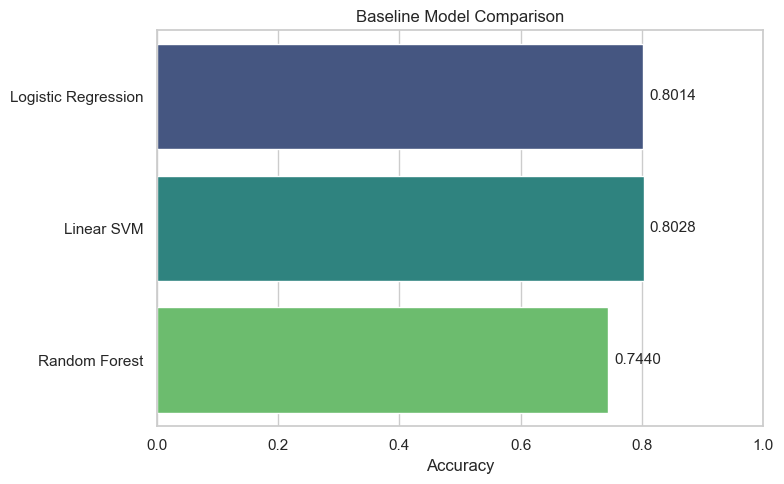

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(8, 5))
names = list(results.keys())
accs = list(results.values())

sns.barplot(x=accs, y=names, ax=ax, palette="viridis")
ax.set_xlabel("Accuracy")
ax.set_title("Baseline Model Comparison")
ax.set_xlim(0, 1)
for i, v in enumerate(accs):
    ax.text(v + 0.01, i, f"{v:.4f}", va="center", fontsize=11)

plt.tight_layout()
plt.show()

## Confusion Matrix (Best Model)

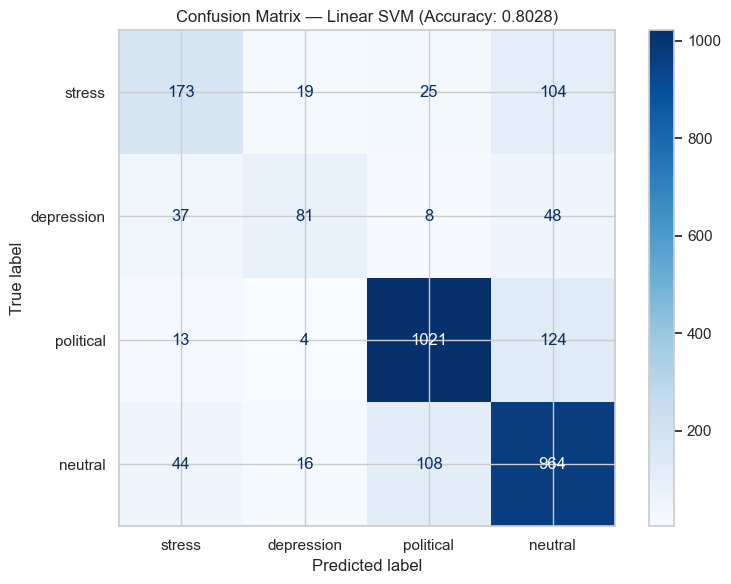

In [6]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

best_name = max(results, key=results.get)
best_model = models[best_name]
y_pred_best = best_model.predict(X_test_tfidf)

fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_best, labels=["stress", "depression", "political", "neutral"])
disp = ConfusionMatrixDisplay(cm, display_labels=["stress", "depression", "political", "neutral"])
disp.plot(ax=ax, cmap="Blues", values_format="d")
ax.set_title(f"Confusion Matrix — {best_name} (Accuracy: {results[best_name]:.4f})")
plt.tight_layout()
plt.show()